# KMeans Clustering on ECG200

This notebook loads ECG200 time-series data from UCR, applies KMeans clustering, and compares discovered clusters to known class labels.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mitigates common MKL warning for KMeans on Windows
os.environ.setdefault('OMP_NUM_THREADS', '1')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
    accuracy_score,
    normalized_mutual_info_score,
    )
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

In [2]:
# Resolve UCR root for common local layouts
root_candidates = [
    (Path('..') / '..' / 'data' / 'UCRArchive_2018').resolve(),
    (Path('..') / '..' / 'data' / 'UCRArchive_2018' / 'UCRArchive_2018').resolve(),
]
UCR_ROOT = next((p for p in root_candidates if p.exists()), root_candidates[0])

dataset_name = 'ECG200'
train_path = UCR_ROOT / dataset_name / f'{dataset_name}_TRAIN.tsv'
test_path = UCR_ROOT / dataset_name / f'{dataset_name}_TEST.tsv'

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        f'Could not find ECG200 files. Checked: {train_path} and {test_path}'
    )

train_df = pd.read_csv(train_path, sep='\t', header=None)
test_df = pd.read_csv(test_path, sep='\t', header=None)
df = pd.concat([train_df, test_df], ignore_index=True)

y_true = df.iloc[:, 0].to_numpy()
X = df.iloc[:, 1:].to_numpy()

print('UCR root:', UCR_ROOT)
print('Dataset:', dataset_name)
print('Samples x Features:', X.shape)
print('Classes:', np.unique(y_true))

UCR root: D:\repositories\personal\xai-spatio-temporal\data\UCRArchive_2018
Dataset: ECG200
Samples x Features: (200, 96)
Classes: [-1  1]


Per-series mean (avg +/- std): 0.0 +/- 0.0
Per-series std  (avg +/- std): 0.9948 +/- 0.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_11404\760574932.py:28: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances.append(np.abs(np.cross(line, p - p1)) / line_norm)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11404\760574932.py:28: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances.append(np.abs(np.cross(line, p - p1)) / line_norm)


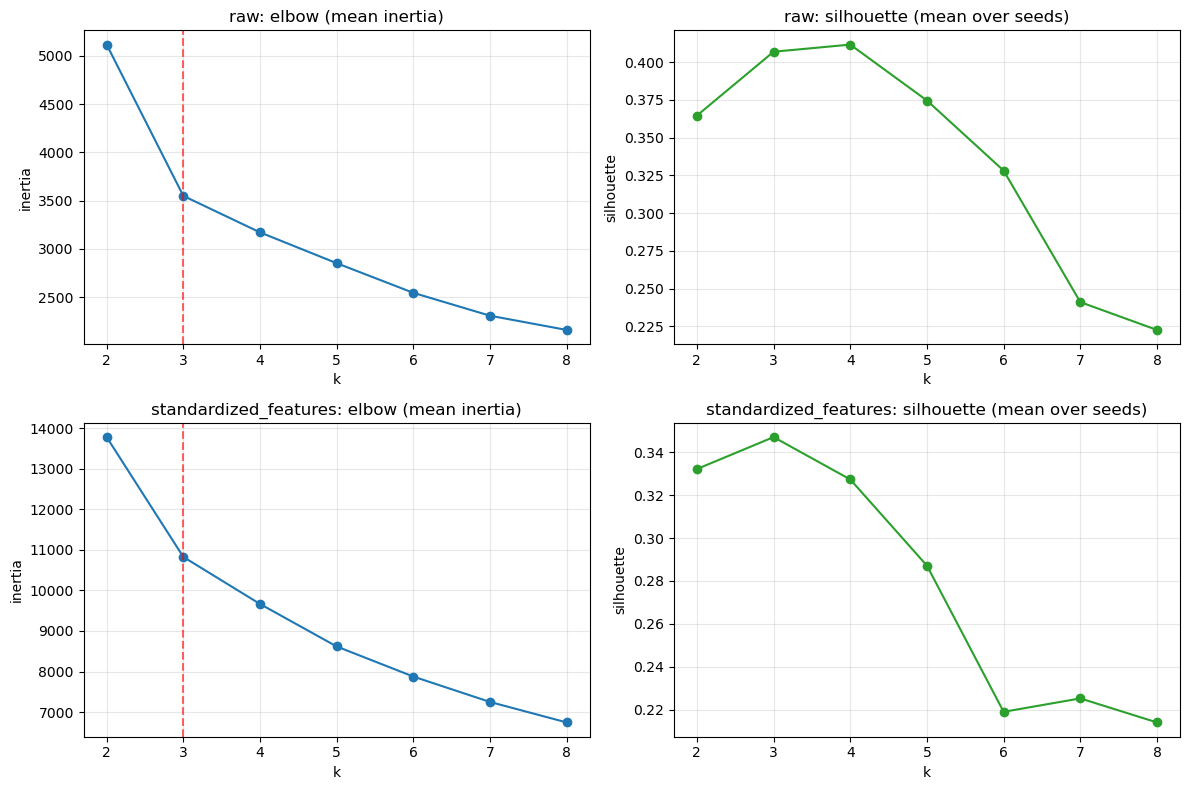

,view,k,silhouette,silhouette_std,calinski_harabasz,davies_bouldin,stability_ari,stability_ari_std,elbow_k,rank_sum,rank_sum_penalized
0,raw,3,0.406866,0.000078,114.966840,1.091254,0.987186,0.015694,3,7.5,7.65
1,raw,4,0.411593,0.002075,93.123024,1.026761,0.974119,0.017584,3,8.0,8.30
2,raw,2,0.364550,0.000000,99.681045,1.104280,1.000000,0.000000,3,11.0,11.00
3,raw,5,0.374555,0.021043,82.720168,1.090755,0.902587,0.083983,3,15.0,15.45
4,raw,6,0.328106,0.003305,78.455021,1.210253,0.971985,0.022027,3,19.0,19.60
5,raw,7,0.240987,0.002091,75.026760,1.340703,0.953860,0.038655,3,23.0,23.75
6,raw,8,0.222550,0.011298,70.206768,1.347883,0.788191,0.079977,3,28.0,28.90
7,standardized_features,3,0.347004,0.000000,76.224264,1.325768,1.000000,0.000000,3,7.5,7.65
8,standardized_features,2,0.332130,0.000000,77.961689,1.339070,1.000000,0.000000,3,9.0,9.00
9,standardized_features,4,0.327282,0.046080,64.454523,1.298804,0.806966,0.181864,3,12.0,12.30


Best k by view: {'raw': 3, 'standardized_features': 3}
Final unsupervised choice (no labels used): {'view': 'raw', 'k': 3}


In [3]:
# Check whether each time series already looks z-normalized
row_means = X.mean(axis=1)
row_stds = X.std(axis=1, ddof=0)
print('Per-series mean (avg +/- std):', round(float(row_means.mean()), 4), '+/-', round(float(row_means.std()), 4))
print('Per-series std  (avg +/- std):', round(float(row_stds.mean()), 4), '+/-', round(float(row_stds.std()), 4))

# Compare raw values vs feature-wise standardization
views = {
    'raw': X,
    'standardized_features': StandardScaler().fit_transform(X),
}

k_values = list(range(2, 9))
seed_list = [0, 1, 2, 3, 4]

def elbow_k_from_line(k_list, inertia_list):
    x = np.asarray(k_list, dtype=float)
    y = np.asarray(inertia_list, dtype=float)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    line = p2 - p1
    line_norm = np.linalg.norm(line)
    if line_norm == 0:
        return int(k_list[0])
    distances = []
    for i in range(len(x)):
        p = np.array([x[i], y[i]])
        distances.append(np.abs(np.cross(line, p - p1)) / line_norm)
    return int(k_list[int(np.argmax(distances))])

rows = []
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, (view_name, X_view) in enumerate(views.items()):
    inertias = []
    silhouettes = []
    silhouettes_std = []
    ch_scores = []
    ch_scores_std = []
    db_scores = []
    db_scores_std = []
    stabilities = []
    stabilities_std = []

    for k in k_values:
        labels_by_seed = []
        inertias_by_seed = []
        sil_by_seed = []
        ch_by_seed = []
        db_by_seed = []

        for seed in seed_list:
            km = KMeans(n_clusters=k, random_state=seed, n_init=20)
            labels = km.fit_predict(X_view)
            labels_by_seed.append(labels)
            inertias_by_seed.append(float(km.inertia_))
            sil_by_seed.append(float(silhouette_score(X_view, labels)))
            ch_by_seed.append(float(calinski_harabasz_score(X_view, labels)))
            db_by_seed.append(float(davies_bouldin_score(X_view, labels)))

        inertias.append(float(np.mean(inertias_by_seed)))
        silhouettes.append(float(np.mean(sil_by_seed)))
        silhouettes_std.append(float(np.std(sil_by_seed, ddof=0)))
        ch_scores.append(float(np.mean(ch_by_seed)))
        ch_scores_std.append(float(np.std(ch_by_seed, ddof=0)))
        db_scores.append(float(np.mean(db_by_seed)))
        db_scores_std.append(float(np.std(db_by_seed, ddof=0)))

        pairwise_ari = []
        for i in range(len(labels_by_seed)):
            for j in range(i + 1, len(labels_by_seed)):
                pairwise_ari.append(adjusted_rand_score(labels_by_seed[i], labels_by_seed[j]))
        stabilities.append(float(np.mean(pairwise_ari)))
        stabilities_std.append(float(np.std(pairwise_ari, ddof=0)))

    elbow_k = elbow_k_from_line(k_values, inertias)

    for i, k in enumerate(k_values):
        rows.append({
            'view': view_name,
            'k': k,
            'inertia': inertias[i],
            'silhouette': silhouettes[i],
            'silhouette_std': silhouettes_std[i],
            'calinski_harabasz': ch_scores[i],
            'calinski_harabasz_std': ch_scores_std[i],
            'davies_bouldin': db_scores[i],
            'davies_bouldin_std': db_scores_std[i],
            'stability_ari': stabilities[i],
            'stability_ari_std': stabilities_std[i],
            'elbow_k': elbow_k,
            'elbow_match': int(k == elbow_k),
        })

    axes[idx, 0].plot(k_values, inertias, marker='o')
    axes[idx, 0].axvline(elbow_k, color='r', linestyle='--', alpha=0.6)
    axes[idx, 0].set_title(f'{view_name}: elbow (mean inertia)')
    axes[idx, 0].set_xlabel('k')
    axes[idx, 0].set_ylabel('inertia')
    axes[idx, 0].grid(alpha=0.3)

    axes[idx, 1].plot(k_values, silhouettes, marker='o', color='tab:green')
    axes[idx, 1].set_title(f'{view_name}: silhouette (mean over seeds)')
    axes[idx, 1].set_xlabel('k')
    axes[idx, 1].set_ylabel('silhouette')
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

selection_df = pd.DataFrame(rows)

for metric in ['silhouette', 'calinski_harabasz', 'stability_ari']:
    selection_df[f'rank_{metric}'] = selection_df.groupby('view')[metric].rank(method='dense', ascending=False)
selection_df['rank_davies_bouldin'] = selection_df.groupby('view')['davies_bouldin'].rank(method='dense', ascending=True)

selection_df['rank_sum'] = (
    selection_df['rank_silhouette']
    + selection_df['rank_calinski_harabasz']
    + selection_df['rank_davies_bouldin']
    + selection_df['rank_stability_ari']
    - 0.5 * selection_df['elbow_match']
    )

# Mild simplicity bias: prefer smaller k when unsupervised scores are close (no labels used)
min_k = min(k_values)
k_penalty = 0.15
selection_df['rank_sum_penalized'] = selection_df['rank_sum'] + k_penalty * (selection_df['k'] - min_k)

selection_df = selection_df.sort_values(
    ['view', 'rank_sum_penalized', 'silhouette', 'stability_ari', 'k'],
    ascending=[True, True, False, False, True],
).reset_index(drop=True)

display(selection_df[[
    'view',
    'k',
    'silhouette',
    'silhouette_std',
    'calinski_harabasz',
    'davies_bouldin',
    'stability_ari',
    'stability_ari_std',
    'elbow_k',
    'rank_sum',
    'rank_sum_penalized',
]])

best_k_by_view = {}
for view_name in views:
    top_row = selection_df[selection_df['view'] == view_name].iloc[0]
    best_k_by_view[view_name] = int(top_row['k'])

best_rows_df = selection_df.groupby('view', as_index=False).first()
final_row = best_rows_df.sort_values(
    ['rank_sum_penalized', 'silhouette', 'stability_ari'],
    ascending=[True, False, False],
).iloc[0]

final_view = str(final_row['view'])
final_k = int(final_row['k'])

print('Best k by view:', best_k_by_view)
print('Final unsupervised choice (no labels used):', {'view': final_view, 'k': final_k})

In [43]:
# Post-hoc label benchmark (uses y_true only for evaluation): compare both views at k=2 and each view-specific best k
def majority_label_mapping(y_ref, clusters):
    mapping = {}
    for c in np.unique(clusters):
        mapping[c] = pd.Series(y_ref[clusters == c]).mode().iloc[0]
    return mapping

def mapped_predictions(clusters, mapping):
    return np.array([mapping[c] for c in clusters])

benchmark_rows = []

for view_name, X_view in views.items():
    k_candidates = sorted(set([2, best_k_by_view[view_name]]))
    for k_eval in k_candidates:
        km_eval = KMeans(n_clusters=k_eval, random_state=42, n_init=50)
        cl_eval = km_eval.fit_predict(X_view)
        map_eval = majority_label_mapping(y_true, cl_eval)
        pred_eval = mapped_predictions(cl_eval, map_eval)

        benchmark_rows.append({
            'view': view_name,
            'k': int(k_eval),
            'mapped_accuracy': float(accuracy_score(y_true, pred_eval)),
            'ari': float(adjusted_rand_score(y_true, cl_eval)),
            'nmi': float(normalized_mutual_info_score(y_true, cl_eval)),
            'silhouette': float(silhouette_score(X_view, cl_eval)),
            'clusters': int(len(np.unique(cl_eval))),
            'classes': int(len(np.unique(y_true))),
        })

benchmark_df = pd.DataFrame(benchmark_rows).sort_values(
    ['view', 'k'], ascending=[True, True]
).reset_index(drop=True)

display(benchmark_df)

print('Note: the table above uses ground-truth labels for evaluation only (not for selecting k/view).')
print('Unsupervised choice (no labels used):', {'view': final_view, 'k': final_k})
print('We still fit both views using their own best k (for comparison and explainability).')

d:\env\py128\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\env\py128\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\env\py128\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\env\py128\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

,view,k,mapped_accuracy,ari,nmi,silhouette,clusters,classes
0,raw,2,0.745,0.219355,0.128859,0.364550,2,2
1,raw,3,0.780,0.312028,0.203882,0.406905,3,2
2,standardized_features,2,0.760,0.252623,0.154967,0.332130,2,2
3,standardized_features,3,0.785,0.321056,0.209782,0.347004,3,2


Note: the table above uses ground-truth labels for evaluation only (not for selecting k/view).
Unsupervised choice (no labels used): {'view': 'raw', 'k': 3}
We still fit both views using their own best k (for comparison and explainability).


In [4]:
# Fit KMeans using each view-specific best k
models_by_view = {}
labels_by_view = {}
summary_rows = []

for view_name, X_view in views.items():
    k_view = best_k_by_view[view_name]
    model = KMeans(n_clusters=k_view, random_state=42, n_init=50)
    labels_view = model.fit_predict(X_view)

    models_by_view[view_name] = model
    labels_by_view[view_name] = labels_view

    summary_rows.append({
        'view': view_name,
        'best_k': int(k_view),
        'inertia': float(model.inertia_),
        'silhouette': float(silhouette_score(X_view, labels_view)),
        'calinski_harabasz': float(calinski_harabasz_score(X_view, labels_view)),
        'davies_bouldin': float(davies_bouldin_score(X_view, labels_view)),
    })

fit_summary_df = pd.DataFrame(summary_rows).sort_values('view').reset_index(drop=True)
display(fit_summary_df)

final_model = models_by_view[final_view]
final_labels = labels_by_view[final_view]
print('Final unsupervised model:', {'view': final_view, 'k': int(final_model.n_clusters)})

,view,best_k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,raw,3,3549.835087,0.406905,114.971914,1.089663
1,standardized_features,3,10823.911649,0.347004,76.224264,1.325768


Final unsupervised model: {'view': 'raw', 'k': 3}


In [35]:
# Compare cluster-vs-label quality for both best-k models
comparison_rows = []

for view_name, X_view in views.items():
    clusters = labels_by_view[view_name]
    comparison = pd.DataFrame({'true_label': y_true, 'cluster': clusters})
    crosstab = pd.crosstab(comparison['true_label'], comparison['cluster'])

    print(f'\nView: {view_name}')
    display(crosstab)

    majority_mapping = {}
    for c in sorted(comparison['cluster'].unique()):
        mode_label = comparison.loc[comparison['cluster'] == c, 'true_label'].mode().iloc[0]
        majority_mapping[c] = mode_label

    predicted_by_cluster = np.array([majority_mapping[c] for c in comparison['cluster']])
    agreement = (predicted_by_cluster == y_true).mean()
    ari_view = adjusted_rand_score(y_true, clusters)
    nmi_view = normalized_mutual_info_score(y_true, clusters)

    print('Cluster -> label mapping:', majority_mapping)
    print('Agreement with true labels (majority-mapped):', round(float(agreement), 4))
    print('Adjusted Rand Index:', round(float(ari_view), 4))
    print('Normalized Mutual Information:', round(float(nmi_view), 4))

    comparison_rows.append({
        'view': view_name,
        'best_k': int(best_k_by_view[view_name]),
        'mapped_accuracy': float(agreement),
        'ari': float(ari_view),
        'nmi': float(nmi_view),
    })

comparison_summary_df = pd.DataFrame(comparison_rows).sort_values('view').reset_index(drop=True)
display(comparison_summary_df)


View: raw


cluster,0,1,2
true_label,,,
-1,11,35,21
1,100,19,14


Cluster -> label mapping: {np.int32(0): np.int64(1), np.int32(1): np.int64(-1), np.int32(2): np.int64(-1)}
Agreement with true labels (majority-mapped): 0.78
Adjusted Rand Index: 0.312
Normalized Mutual Information: 0.2039

View: standardized_features


cluster,0,1,2
true_label,,,
-1,21,11,35
1,13,101,19


Cluster -> label mapping: {np.int32(0): np.int64(-1), np.int32(1): np.int64(1), np.int32(2): np.int64(-1)}
Agreement with true labels (majority-mapped): 0.785
Adjusted Rand Index: 0.3211
Normalized Mutual Information: 0.2098


,view,best_k,mapped_accuracy,ari,nmi
0,raw,3,0.780,0.312028,0.203882
1,standardized_features,3,0.785,0.321056,0.209782


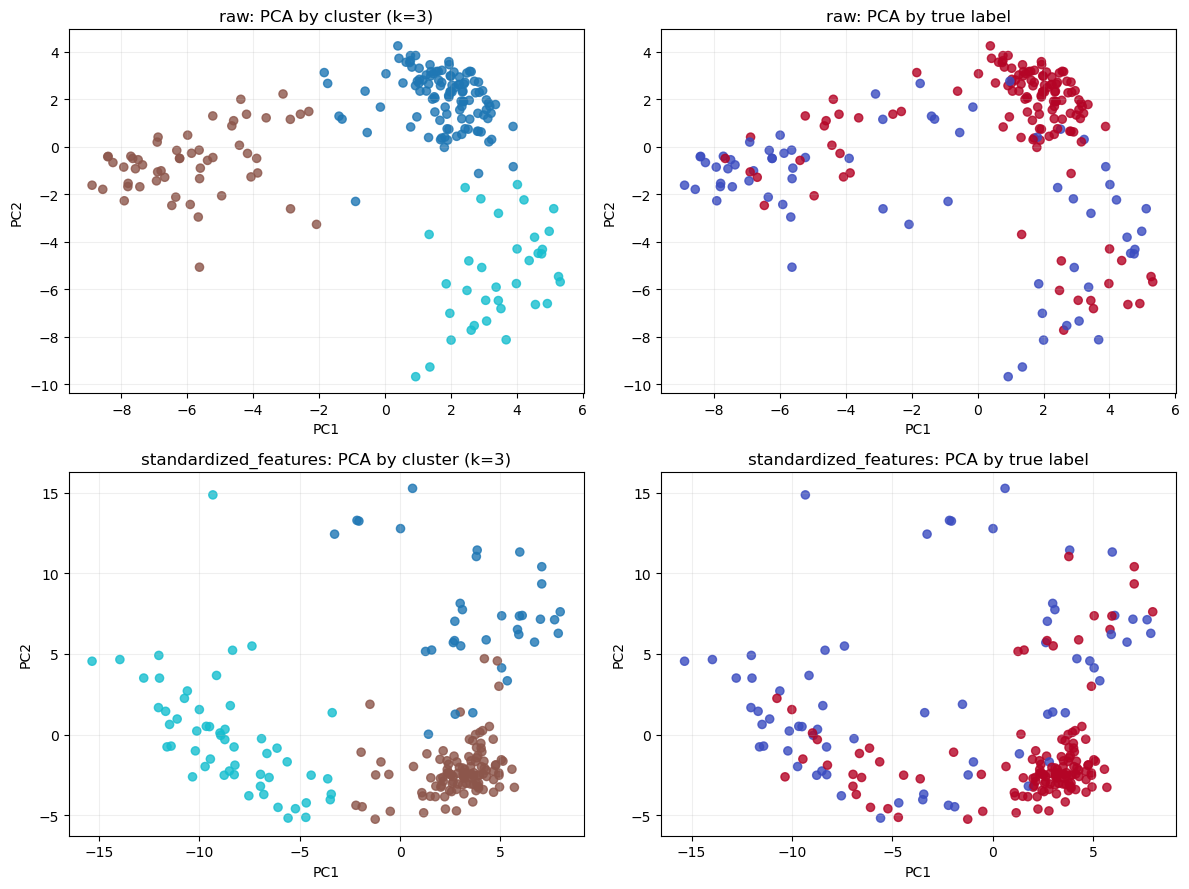

In [36]:
# 2D projection for visual inspection (both views with own best k)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for row_idx, view_name in enumerate(['raw', 'standardized_features']):
    X_view = views[view_name]
    clusters = labels_by_view[view_name]
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_view)

    axes[row_idx, 0].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, s=35, cmap='tab10', alpha=0.8)
    axes[row_idx, 0].set_title(f'{view_name}: PCA by cluster (k={best_k_by_view[view_name]})')
    axes[row_idx, 0].set_xlabel('PC1')
    axes[row_idx, 0].set_ylabel('PC2')
    axes[row_idx, 0].grid(alpha=0.2)

    axes[row_idx, 1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, s=35, cmap='coolwarm', alpha=0.8)
    axes[row_idx, 1].set_title(f'{view_name}: PCA by true label')
    axes[row_idx, 1].set_xlabel('PC1')
    axes[row_idx, 1].set_ylabel('PC2')
    axes[row_idx, 1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


View: raw
Surrogate tree train fidelity: 0.985
Surrogate tree CV fidelity: 0.94

Surrogate rules:

|--- t_41 <= -0.60
|   |--- class: 1
|--- t_41 >  -0.60
|   |--- t_30 <= -1.45
|   |   |--- t_12 <= -0.76
|   |   |   |--- class: 0
|   |   |--- t_12 >  -0.76
|   |   |   |--- class: 0
|   |--- t_30 >  -1.45
|   |   |--- t_30 <= -0.70
|   |   |   |--- class: 2
|   |   |--- t_30 >  -0.70
|   |   |   |--- class: 2



,feature,importance
41,t_41,0.570841
30,t_30,0.427106
12,t_12,0.002053
2,t_2,0.000000
4,t_4,0.000000
5,t_5,0.000000
6,t_6,0.000000
0,t_0,0.000000
7,t_7,0.000000
8,t_8,0.000000


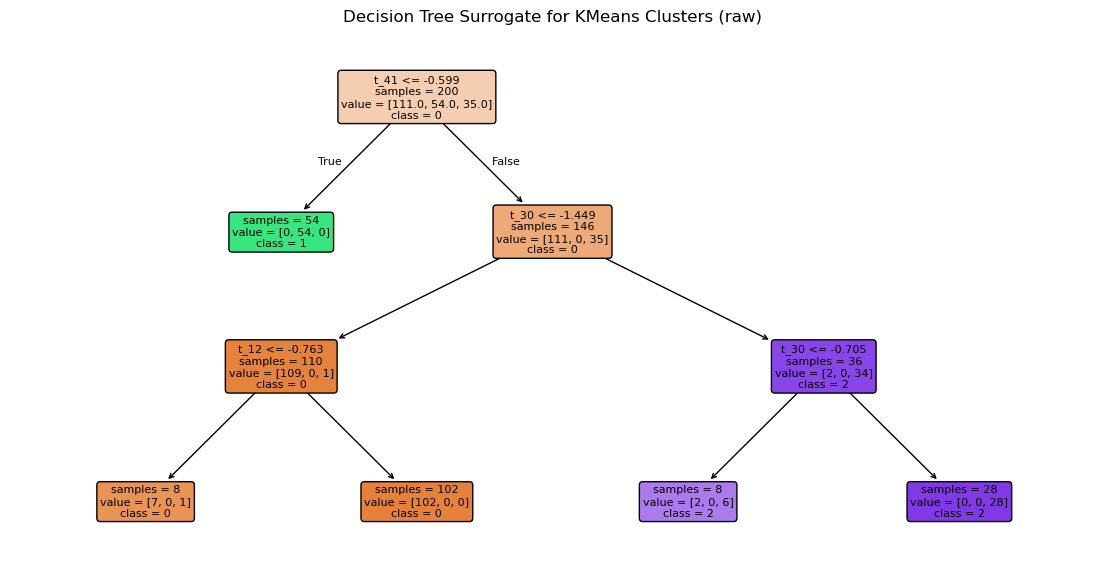


View: standardized_features
Surrogate tree train fidelity: 0.995
Surrogate tree CV fidelity: 0.975

Surrogate rules:

|--- t_41 <= -0.65
|   |--- class: 2
|--- t_41 >  -0.65
|   |--- t_31 <= 0.51
|   |   |--- class: 1
|   |--- t_31 >  0.51
|   |   |--- t_21 <= -0.75
|   |   |   |--- class: 0
|   |   |--- t_21 >  -0.75
|   |   |   |--- class: 0



,feature,importance
41,t_41,0.562261
31,t_31,0.436064
21,t_21,0.001675
0,t_0,0.000000
4,t_4,0.000000
5,t_5,0.000000
2,t_2,0.000000
1,t_1,0.000000
8,t_8,0.000000
9,t_9,0.000000


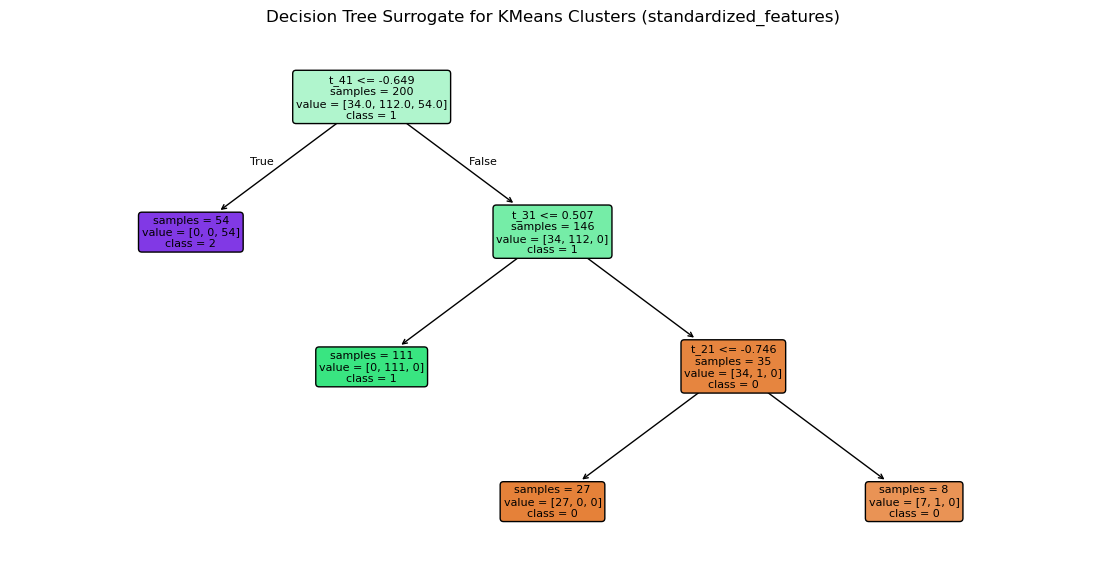

In [5]:
# Train surrogate decision trees for both views (no single-view selection)
surrogates_by_view = {}

for view_name, X_used in views.items():
    cluster_labels = labels_by_view[view_name]
    feature_names = [f't_{i}' for i in range(X_used.shape[1])]

    surrogate = DecisionTreeClassifier(max_depth=3, min_samples_leaf=8, random_state=42)
    surrogate.fit(X_used, cluster_labels)

    surrogate_pred = surrogate.predict(X_used)
    train_fidelity = accuracy_score(cluster_labels, surrogate_pred)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_fidelity = cross_val_score(
        surrogate, X_used, cluster_labels, cv=cv, scoring='accuracy'
    ).mean()

    print(f'\nView: {view_name}')
    print('Surrogate tree train fidelity:', round(float(train_fidelity), 4))
    print('Surrogate tree CV fidelity:', round(float(cv_fidelity), 4))

    rules = export_text(surrogate, feature_names=feature_names)
    print('\nSurrogate rules:\n')
    print(rules)

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': surrogate.feature_importances_,
    }).sort_values('importance', ascending=False)

    display(importance_df.head(10))

    plt.figure(figsize=(14, 7))
    plot_tree(
        surrogate,
        feature_names=feature_names,
        class_names=[str(c) for c in sorted(np.unique(cluster_labels))],
        filled=True,
        rounded=True,
        impurity=False,
        fontsize=8,
    )
    plt.title(f'Decision Tree Surrogate for KMeans Clusters ({view_name})')
    plt.show()

    surrogates_by_view[view_name] = {
        'surrogate': surrogate,
        'X_used': X_used,
        'cluster_labels': cluster_labels,
        'feature_names': feature_names,
    }


View: raw


,feature,mean_abs_shap
0,t_41,0.262800
1,t_30,0.169943
2,t_12,0.009165
3,t_2,0.000000
4,t_4,0.000000
5,t_5,0.000000
6,t_6,0.000000
7,t_0,0.000000
8,t_7,0.000000
9,t_8,0.000000


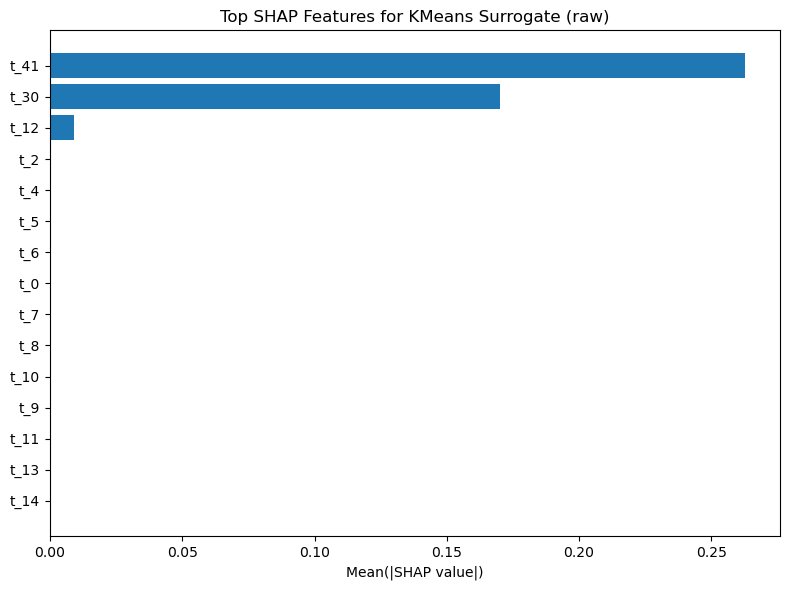

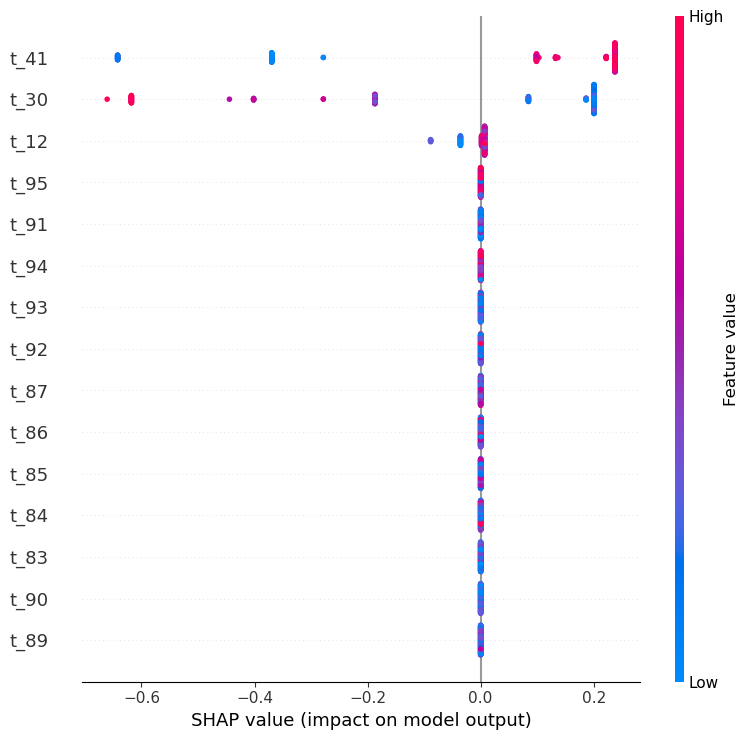


View: standardized_features


,feature,mean_abs_shap
0,t_41,0.262800
1,t_31,0.165775
2,t_21,0.007494
3,t_0,0.000000
4,t_4,0.000000
5,t_5,0.000000
6,t_2,0.000000
7,t_1,0.000000
8,t_8,0.000000
9,t_9,0.000000


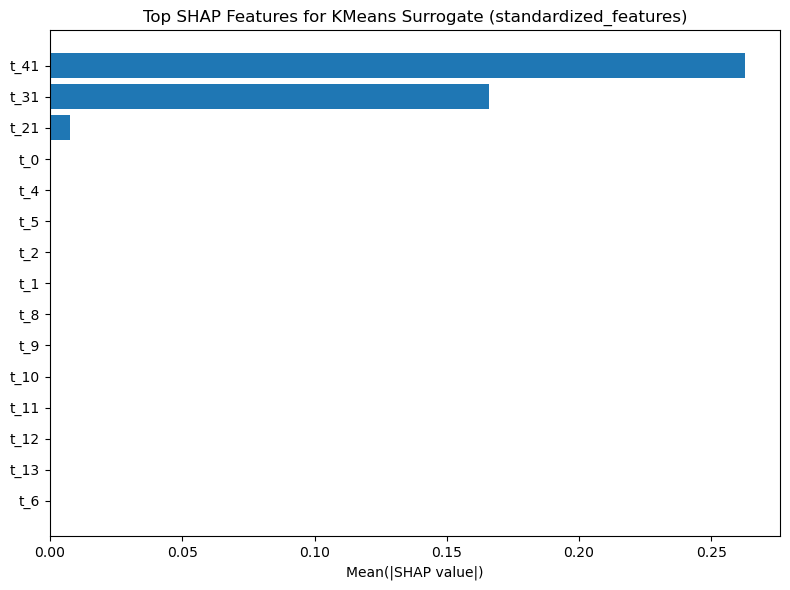

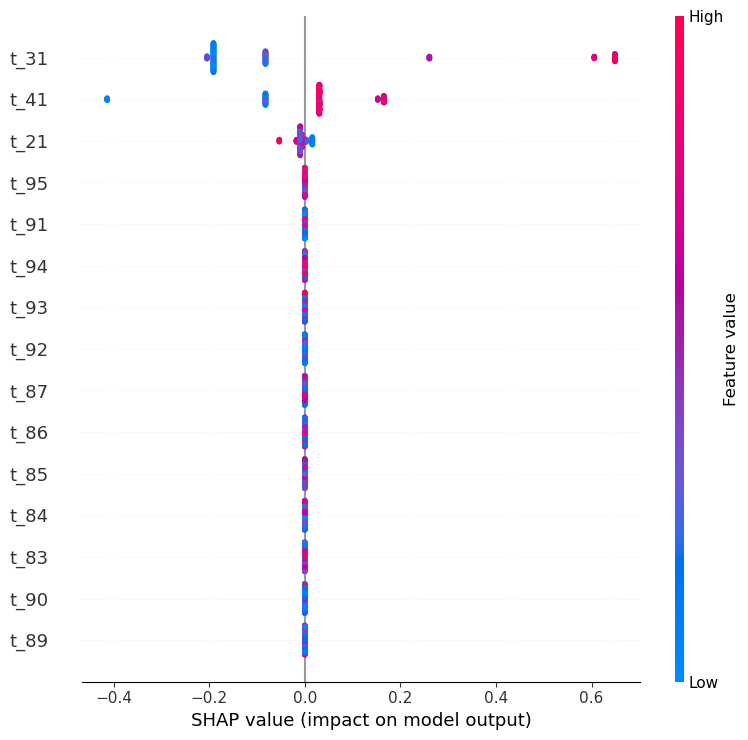

In [41]:
# SHAP feature attributions for surrogate trees in both views
try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print('SHAP is not installed in this environment. Install with: pip install shap')

if shap_available:
    for view_name, payload in surrogates_by_view.items():
        surrogate = payload['surrogate']
        X_used = payload['X_used']
        feature_names = payload['feature_names']

        explainer = shap.TreeExplainer(surrogate)
        raw_shap = explainer.shap_values(X_used)

        # Aggregate class-wise outputs for multiclass trees
        if isinstance(raw_shap, list):
            # One array per class: [n_samples, n_features]
            shap_abs_mean = np.mean(
                np.stack([np.abs(class_values).mean(axis=0) for class_values in raw_shap], axis=0),
                axis=0,
            )
            shap_for_beeswarm = raw_shap[0]
        elif isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
            # [n_samples, n_features, n_classes]
            shap_abs_mean = np.abs(raw_shap).mean(axis=(0, 2))
            shap_for_beeswarm = raw_shap[:, :, 0]
        else:
            # [n_samples, n_features]
            shap_abs_mean = np.abs(raw_shap).mean(axis=0)
            shap_for_beeswarm = raw_shap

        shap_importance_df = pd.DataFrame({
            'feature': feature_names,
            'mean_abs_shap': shap_abs_mean,
        }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

        print(f'\nView: {view_name}')
        display(shap_importance_df.head(15))

        top_n = 15
        top_df = shap_importance_df.head(top_n).iloc[::-1]
        plt.figure(figsize=(8, 6))
        plt.barh(top_df['feature'], top_df['mean_abs_shap'])
        plt.title(f'Top SHAP Features for KMeans Surrogate ({view_name})')
        plt.xlabel('Mean(|SHAP value|)')
        plt.tight_layout()
        plt.show()

        # Red/blue SHAP summary style like your example
        try:
            shap.summary_plot(
                shap_for_beeswarm,
                pd.DataFrame(X_used, columns=feature_names),
                max_display=15,
                show=True,
            )
        except Exception as ex:
            print('Could not render SHAP beeswarm summary:', ex)

## SHAP explanation of KMeans surrogate

The SHAP values below explain the surrogate decision tree that approximates KMeans assignments. This gives feature-level attribution for why a sample is routed to a particular cluster region.

## Why KMeans can be explainable

KMeans is prototype-based: each cluster has a centroid, and each sample is assigned to the nearest centroid in Euclidean distance. This is interpretable through centroid shapes and distance-to-centroid logic.

A practical way to explain assignments is to train a shallow surrogate model (for example, a decision tree) to predict KMeans cluster labels from the same features. High surrogate fidelity means the tree captures most of KMeans behavior in readable rules.

In [45]:
feature_idx = 41
print("Raw dataframe columns shown: [label, t_41]")
display(df.iloc[:10, [0, 1 + feature_idx]])

print("Same values as numpy X[:, 41] (first 10):")
print(X[:10, feature_idx])

print("Range/quantiles of t_41 (raw view):")
vals = views["raw"][:, feature_idx]
print(np.quantile(vals, [0, 0.01, 0.05, 0.5, 0.95, 0.99, 1.0]))

Raw dataframe columns shown: [label, t_41]


,0,42
0,-1,-1.423810
1,1,0.750518
2,-1,-1.509483
3,-1,-1.729149
4,1,0.700880
5,1,0.194320
6,-1,-1.735507
7,-1,-0.706255
8,1,0.606465
9,1,0.655109


Same values as numpy X[:, 41] (first 10):
[-1.4238097   0.75051788 -1.5094832  -1.7291486   0.70087985  0.19431966
 -1.7355071  -0.70625453  0.60646546  0.65510886]
Range/quantiles of t_41 (raw view):
[-1.9967517  -1.89403023 -1.74000543  0.49020393  0.95396227  1.10667391
  1.3428101 ]


## Abductive explanations for raw time-series clustering

This section computes abductive edits from the surrogate rules for both raw approaches (`raw` and `standardized_features`). For each sampled point, it reports a minimal rule-consistent feature edit that flips the surrogate cluster prediction.

In [6]:
def _leaf_constraints(tree_):
    n_features = tree_.n_features
    constraints = {}

    def walk(node_id, low, high):
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]

        if left_id == right_id:
            constraints[node_id] = (low.copy(), high.copy())
            return

        feat = tree_.feature[node_id]
        thr = tree_.threshold[node_id]

        high_left = high.copy()
        high_left[feat] = min(high_left[feat], thr)
        walk(left_id, low.copy(), high_left)

        low_right = low.copy()
        low_right[feat] = max(low_right[feat], np.nextafter(thr, np.inf))
        walk(right_id, low_right, high.copy())

    walk(
        0,
        np.full(n_features, -np.inf, dtype=float),
        np.full(n_features, np.inf, dtype=float),
    )
    return constraints


def _as_scalar_label(value):
    try:
        return int(value)
    except Exception:
        return value


def _best_abductive_edit(surrogate, x_row, feature_names, max_display_features=6):
    tree_ = surrogate.tree_
    leaf_rules = _leaf_constraints(tree_)
    classes = surrogate.classes_

    current_label = surrogate.predict(x_row.reshape(1, -1))[0]
    current_label_scalar = _as_scalar_label(current_label)

    best = None
    for leaf_id, (low, high) in leaf_rules.items():
        target_idx = int(np.argmax(tree_.value[leaf_id][0]))
        target_label = classes[target_idx]
        target_label_scalar = _as_scalar_label(target_label)

        if target_label_scalar == current_label_scalar:
            continue

        x_new = x_row.astype(float).copy()
        edits = []
        for feat_idx in range(x_new.shape[0]):
            old_val = float(x_new[feat_idx])
            new_val = old_val

            if old_val < low[feat_idx]:
                new_val = float(low[feat_idx])
            elif old_val > high[feat_idx]:
                new_val = float(high[feat_idx])

            if new_val != old_val:
                x_new[feat_idx] = new_val
                edits.append((feat_idx, old_val, new_val, abs(new_val - old_val)))

        predicted_new = surrogate.predict(x_new.reshape(1, -1))[0]
        predicted_new_scalar = _as_scalar_label(predicted_new)
        if predicted_new_scalar != target_label_scalar:
            continue

        n_changed = len(edits)
        total_shift = float(sum(item[3] for item in edits))

        changed_features = [feature_names[item[0]] for item in edits]
        edits_preview = '; '.join(
            [
                f"{feature_names[item[0]]}: {item[1]:.3f} -> {item[2]:.3f}"
                for item in edits[:max_display_features]
            ]
        )

        candidate = {
            'original_cluster': current_label_scalar,
            'target_cluster': target_label_scalar,
            'n_features_changed': n_changed,
            'total_abs_shift': total_shift,
            'changed_features': ', '.join(changed_features),
            'suggested_edits': edits_preview,
        }

        if best is None:
            best = candidate
        else:
            current_score = (candidate['n_features_changed'], candidate['total_abs_shift'])
            best_score = (best['n_features_changed'], best['total_abs_shift'])
            if current_score < best_score:
                best = candidate

    return best


raw_abductive_by_view = {}
for view_name, payload in surrogates_by_view.items():
    surrogate = payload['surrogate']
    X_used = np.asarray(payload['X_used'])
    feature_names = payload['feature_names']

    sample_count = min(12, X_used.shape[0])
    sample_indices = np.unique(np.linspace(0, X_used.shape[0] - 1, num=sample_count, dtype=int))

    rows = []
    for idx in sample_indices:
        best_edit = _best_abductive_edit(surrogate, X_used[idx], feature_names)
        if best_edit is None:
            continue
        rows.append({'sample_idx': int(idx), **best_edit})

    abductive_df = pd.DataFrame(rows)
    raw_abductive_by_view[view_name] = abductive_df

    print(f'\nView: {view_name} (abductive explanations from surrogate rules)')
    if abductive_df.empty:
        print('No abductive edits found for the sampled points.')
    else:
        display(abductive_df.head(12))
        summary = abductive_df[['n_features_changed', 'total_abs_shift']].agg(['mean', 'min', 'max'])
        print('Abductive summary stats:')
        display(summary)


View: raw (abductive explanations from surrogate rules)


,sample_idx,original_cluster,target_cluster,n_features_changed,total_abs_shift,changed_features,suggested_edits
0,18,0,1,1,0.557046,t_41,t_41: -0.042 -> -0.599
1,36,2,0,1,0.766994,t_30,t_30: -0.682 -> -1.449
2,54,0,1,1,1.349054,t_41,t_41: 0.750 -> -0.599
3,108,0,2,1,1.304249,t_30,t_30: -2.009 -> -0.705
4,144,0,2,1,1.409746,t_30,t_30: -2.115 -> -0.705
5,162,0,2,1,0.798544,t_30,t_30: -1.503 -> -0.705
6,180,0,1,1,0.954326,t_41,t_41: 0.355 -> -0.599


Abductive summary stats:


,n_features_changed,total_abs_shift
mean,1.0,1.019994
min,1.0,0.557046
max,1.0,1.409746



View: standardized_features (abductive explanations from surrogate rules)


,sample_idx,original_cluster,target_cluster,n_features_changed,total_abs_shift,changed_features,suggested_edits
0,0,2,1,1,0.872621,t_41,t_41: -1.521 -> -0.649
1,18,1,0,1,0.812386,t_31,t_31: -0.305 -> 0.507
2,54,1,0,1,1.403419,t_31,t_31: -0.896 -> 0.507
3,72,2,1,1,0.786707,t_41,t_41: -1.435 -> -0.649
4,90,2,0,1,0.996333,t_41,t_41: -1.645 -> -0.649
5,108,1,0,1,1.158278,t_31,t_31: -0.651 -> 0.507
6,126,2,1,1,0.847709,t_41,t_41: -1.496 -> -0.649
7,144,1,0,1,0.935651,t_31,t_31: -0.428 -> 0.507
8,162,1,0,1,0.480864,t_31,t_31: 0.027 -> 0.507
9,180,1,0,1,1.217562,t_31,t_31: -0.710 -> 0.507


Abductive summary stats:


,n_features_changed,total_abs_shift
mean,1.0,0.889101
min,1.0,0.268586
max,1.0,1.403419
